# Notebook 03: Serving Demo

In [15]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..'))

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

BASE_URL = 'http://localhost:8000'
print('Base URL:', BASE_URL)

Base URL: http://localhost:8000


## 1. Health Check

In [16]:
resp = requests.get(f'{BASE_URL}/health')
data = resp.json()

print(f'Status        : {data["status"]}')
print(f'Models loaded : {data["models_loaded"]}')
print(f'Best model    : {data["best_model"]}')

Status        : ok
Models loaded : ['ridge', 'xgboost', 'lightgbm']
Best model    : LightGBM


## 2. Xem Model Metrics

In [17]:
resp = requests.get(f'{BASE_URL}/models')
print(json.dumps(resp.json(), indent=2))

{
  "models": {
    "ridge": {
      "loaded": true,
      "MAE": "N/A",
      "RMSE": "N/A",
      "MAPE%": "N/A",
      "is_best": false
    },
    "xgboost": {
      "loaded": true,
      "MAE": "N/A",
      "RMSE": "N/A",
      "MAPE%": "N/A",
      "is_best": false
    },
    "lightgbm": {
      "loaded": true,
      "MAE": "N/A",
      "RMSE": "N/A",
      "MAPE%": "N/A",
      "is_best": false
    }
  },
  "best_model": "LightGBM"
}


## 3. Single Prediction

In [18]:
# Lấy 1 row từ test set để predict thật
X_test = pd.read_parquet('../data/processed/X_test.parquet')
y_test = pd.read_parquet('../data/processed/y_test.parquet')['units_ordered']

# Lấy row đầu tiên
row = X_test.iloc[0].to_dict()
actual = float(y_test.iloc[0])

print('Input features:')
for k, v in row.items():
    print(f'  {k:25s}: {v}')
print(f'\nActual value: {actual}')

Input features:
  day_of_week              : 4.0
  week_of_year             : 23.0
  month                    : 6.0
  year                     : 2024.0
  is_weekend               : 0.0
  lag_1                    : 0.6
  lag_7                    : 0.9
  lag_14                   : 0.3
  lag_28                   : 0.7
  rolling_mean_7           : 0.8142857142857274
  rolling_mean_14          : 0.8071428571428562
  rolling_std_7            : 0.279455252402543
  discount_pct             : 0.019000000000000017
  is_promotion             : 0.0
  holiday                  : 0.0
  stockout_lag_1           : 1.0
  product_category         : 4.0
  product_subcategory      : 28.0
  location                 : 0.0
  store_id                 : 238.0
  avg_temperature          : 25.47
  avg_humidity             : 73.39
  avg_wind_level           : 1.84
  precpt                   : 1.8203

Actual value: 0.6


In [19]:
# Call API
resp = requests.post(f'{BASE_URL}/predict', json=row)
result = resp.json()

print(f'Predicted : {result["prediction"]}')
print(f'Actual    : {actual}')
print(f'Error     : {abs(result["prediction"] - actual):.4f}')
print(f'Model used: {result["model_used"]}')

Predicted : 0.7717
Actual    : 0.6
Error     : 0.1717
Model used: lightgbm


## 4. Compare 3 models from the same input

In [20]:
print(f'Actual value: {actual}\n')
print(f'{"Model":<15} {"Prediction":>12} {"Error":>10}')
print('-' * 40)

for model_name in ['ridge', 'xgboost', 'lightgbm']:
    payload = {**row, 'model_name': model_name}
    resp    = requests.post(f'{BASE_URL}/predict', json=payload)
    pred    = resp.json()['prediction']
    error   = abs(pred - actual)
    print(f'{model_name:<15} {pred:>12.4f} {error:>10.4f}')

Actual value: 0.6

Model             Prediction      Error
----------------------------------------
ridge                 0.6086     0.0086
xgboost               0.7800     0.1800
lightgbm              0.7717     0.1717


## 5. Batch Prediction — 50 rows from test set

In [21]:
# Lấy 50 rows
N = 50
batch_rows   = X_test.iloc[:N].to_dict(orient='records')
actual_vals  = y_test.iloc[:N].values

resp = requests.post(
    f'{BASE_URL}/predict/batch',
    json={'requests': batch_rows}
)
batch_result = resp.json()

print(f'Count      : {batch_result["count"]}')
print(f'Model used : {batch_result["model_used"]}')

preds = np.array(batch_result['predictions'])
mae   = np.mean(np.abs(actual_vals - preds))
print(f'MAE (batch): {mae:.4f}')

Count      : 50
Model used : lightgbm
MAE (batch): 0.2646


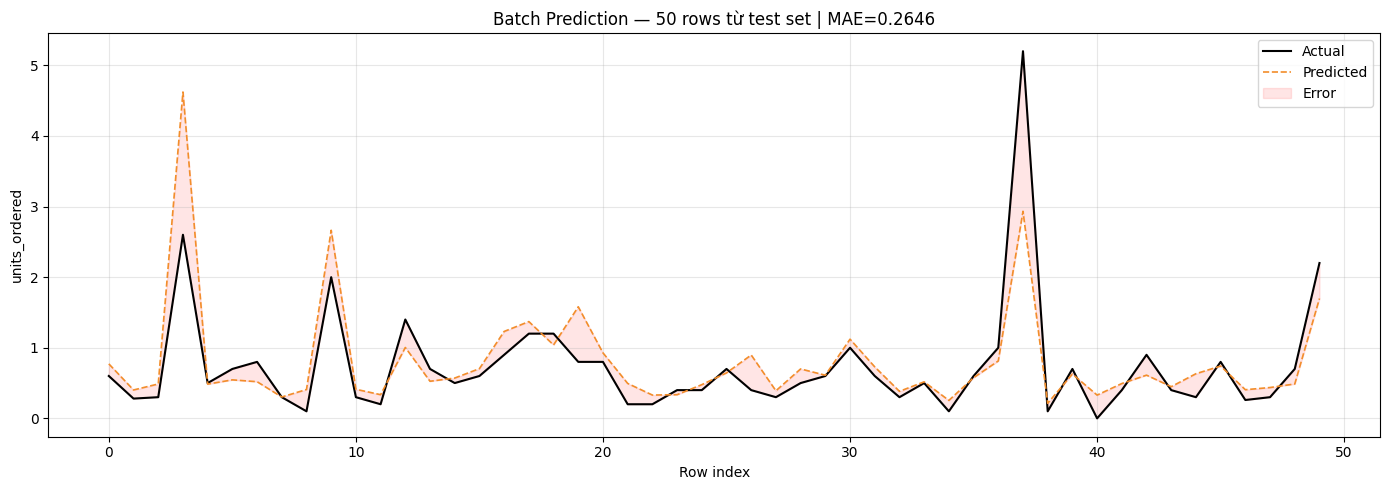

In [ ]:
# Plot: actual vs predicted on 50 rows
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(actual_vals, label='Actual',    color='black',   linewidth=1.5)
ax.plot(preds,       label='Predicted', color='#f28e2b', linewidth=1.2, linestyle='--')
ax.fill_between(range(N), actual_vals, preds, alpha=0.1, color='red', label='Error')
ax.set_title(f'Batch Prediction — {N} rows from test set | MAE={mae:.4f}')
ax.set_xlabel('Row index')
ax.set_ylabel('units_ordered')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../models/batch_prediction_demo.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Watch Feature List from API

In [23]:
resp = requests.get(f'{BASE_URL}/features')
data = resp.json()

print(f'Total features: {data["total_features"]}')
print(f'Target        : {data["target_col"]}')
print(f'Features      :')
for i, col in enumerate(data['feature_cols'], 1):
    print(f'  {i:2d}. {col}')

Total features: 24
Target        : units_ordered
Features      :
   1. day_of_week
   2. week_of_year
   3. month
   4. year
   5. is_weekend
   6. lag_1
   7. lag_7
   8. lag_14
   9. lag_28
  10. rolling_mean_7
  11. rolling_mean_14
  12. rolling_std_7
  13. discount_pct
  14. is_promotion
  15. holiday
  16. stockout_lag_1
  17. product_category
  18. product_subcategory
  19. location
  20. store_id
  21. avg_temperature
  22. avg_humidity
  23. avg_wind_level
  24. precpt


---
## Summary
Swagger UI at: **http://localhost:8000/docs**